# Image Recognition & Segmentation

Two-stage pipeline that improves color extraction by first classifying product type, then applying type-conditional color extraction. Includes evaluation against ground truth and an active learning cycle to improve the classifier.

**Stage 1: Classifier:** ResNet-18 fine-tuned on four container types: `swatch`, `bullet_lipstick`, `liquid_lipstick`, `other`.

**Stage 2: Segmenters:** Two U-Nets (ResNet-18 encoder, ImageNet pretrained) each trained on their respective class:
- `bullet_lipstick` + `liquid_lipstick` → `unet_segmenter.pth`
- `other` (transparent/closed containers) → `unet_segmenter_other.pth`

**Routing logic:**
- `swatch` → median LAB after white/black background removal (no segmentation)
- `bullet_lipstick` / `liquid_lipstick` → U-Net mask → median LAB from masked pixels
- `other` → separate U-Net mask → dominant cluster LAB from masked pixels (clustering separates true color from mixed container pixels)

**Evaluation:** Delta E CIE 2000 vs. ground-truth LAB per container type; five extraction strategies compared (mean, median, trimmed mean, dominant cluster, shadow-filtered) to select the best per type.

**Active learning:** classifier uncertainty is scored on out-of-training images; low-confidence predictions are exported as an annotation queue, corrected labels are merged back, and Stage 1 is fine-tuned on the expanded dataset.

**Inputs:** `data/processed/annotations_combined.csv`, `data/img/annotation_sample/`, `data/img/annotation_sample_closed/`, `data/processed/annotations_label_studio_closed_addition.json`

**Outputs:** `models/resnet18_classifier.pth`, `models/unet_segmenter.pth`, `models/unet_segmenter_other.pth`, `models/resnet18_classifier_al.pth`, `data/annotations/labels.csv`, `data/annotations/masks/`, `data/annotations/active_learning_queue.csv`

In [151]:
import os
import sys
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from skimage import color as skcolor
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
import segmentation_models_pytorch as smp
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

BASE = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, BASE)

DATA       = os.path.join(BASE, 'data', 'processed')
IMG        = os.path.join(BASE, 'data', 'img')
ANN_DIR    = os.path.join(BASE, 'data', 'annotations')
MASKS_DIR  = os.path.join(ANN_DIR, 'masks')
MODELS_DIR = os.path.join(BASE, 'models')
IMG_SAMPLE = os.path.join(IMG, 'annotation_sample')
IMG_CLOSED = os.path.join(IMG, 'annotation_sample_closed')
IMG_DIRS   = [IMG_SAMPLE, IMG_CLOSED]

os.makedirs(MASKS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

DEVICE = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device: {DEVICE}  |  seed: {SEED}')

device: mps  |  seed: 42


## 1. Data Preparation

In [152]:
# Remap annotation labels to classifier classes
LABEL_MAP = {
    'bullet': 'bullet_lipstick',
    'liquid': 'liquid_lipstick',
    'swatch': 'swatch',
    'closed': 'other',
}
CLASSES = ['bullet_lipstick', 'liquid_lipstick', 'other', 'swatch']  # sorted alphabetically

df = pd.read_csv(os.path.join(DATA, 'annotations_combined.csv'))
df = df[df['label'] != 'color_not_shown'].copy()
df['label'] = df['label'].map(LABEL_MAP)
print(df['label'].value_counts())
print(f'\n{len(df)} annotated images')

label
swatch             105
bullet_lipstick     61
liquid_lipstick     47
other               34
Name: count, dtype: int64

247 annotated images


In [153]:
from label_studio_converter.brush import decode_rle as _ls_decode_rle

def find_image(img_name, img_dirs=IMG_DIRS):
    for d in img_dirs:
        p = os.path.join(d, img_name)
        if os.path.exists(p):
            return p
    return None

def decode_rle(rle, height, width):
    """Decode Label Studio brush RLE to a binary mask (H x W, uint8).
    Label Studio encodes brush strokes as RGBA; the mask region is the alpha channel (index 3).
    """
    flat = _ls_decode_rle(rle)           # → length h*w*4, row-major RGBA bytes
    rgba = flat.reshape(height, width, 4)
    return (rgba[:, :, 3] > 0).astype(np.uint8)

In [154]:
import re

def resolve_img_name(img_name):
    """Map a Label Studio img_name to the actual filename on disk.
    When two images shared a base filename, Label Studio appended _XXXXXXX (7 alphanumeric chars)
    before the extension. Strip the suffix to find the real file, but keep the original name for traceability.
    """
    if find_image(img_name) is not None:
        return img_name
    base = re.sub(r'_[A-Za-z0-9]{7}(\.jpg)$', r'\1', img_name)
    if base != img_name and find_image(base) is not None:
        return base
    return None  # unresolvable

df['img_name_disk'] = df['img_name'].apply(resolve_img_name)
found    = df['img_name_disk'].notna().sum()
not_found = df['img_name_disk'].isna().sum()
print(f'{found} images resolved to a file on disk, {not_found} unresolvable')
print(df[['img_name', 'img_name_disk']].head(3))

198 images resolved to a file on disk, 49 unresolvable
                                            img_name  \
0  lipstick__aboutface__paintit_matte_lip_color__...   
1  lipstick__anastasia_beverly_hills__liquid_lips...   
2  lipstick__anastasia_beverly_hills__liquid_lips...   

                                       img_name_disk  
0  lipstick__aboutface__paintit_matte_lip_color__...  
1  lipstick__anastasia_beverly_hills__liquid_lips...  
2  lipstick__anastasia_beverly_hills__liquid_lips...  


In [155]:
# Decode RLE masks from Label Studio JSON → save as PNG in data/annotations/masks/
with open(os.path.join(DATA, 'annotations_label_studio_closed_addition.json')) as f:
    raw = json.load(f)

task_lookup = {}
for task in raw:
    img_name = os.path.basename(task['data']['image'])
    img_name = img_name.split('-', 1)[-1] if '-' in img_name else img_name
    ann = task['annotations'][0]
    if not ann['result']:
        continue
    task_lookup[img_name] = ann['result'][0]  # store full result entry (h/w are here, not in ['value'])

saved, skipped = 0, 0
for _, row in df.iterrows():
    stem = os.path.splitext(row['img_name'])[0]
    out_path = os.path.join(MASKS_DIR, stem + '.png')
    if row['img_name'] not in task_lookup:
        skipped += 1
        continue
    entry = task_lookup[row['img_name']]
    rle = entry['value'].get('rle', [])
    h   = entry.get('original_height', 0)
    w   = entry.get('original_width', 0)
    if not rle or not h or not w:
        skipped += 1
        continue
    mask = decode_rle(rle, h, w)
    Image.fromarray(mask * 255).save(out_path)
    saved += 1

print(f'Saved {saved} masks, skipped {skipped}')

Saved 247 masks, skipped 0


In [156]:
# Join with ground-truth LAB values and save data/annotations/labels.csv
products = pd.read_csv(os.path.join(DATA, 'products_with_images.csv'))
gt = products[products['ground_truth_CIELAB'].notna()][['img_name', 'ground_truth_CIELAB']].copy()

# Normalize GT img_names to .jpg — annotation_sample uses original_clean/ which converts everything to .jpg
gt['img_name_disk'] = gt['img_name'].apply(lambda n: os.path.splitext(n)[0] + '.jpg')

def parse_cielab(s):
    arr = np.fromstring(str(s).strip('[]'), sep=' ')
    return pd.Series({'true_L': arr[0], 'true_a': arr[1], 'true_b': arr[2]})

gt = gt.join(gt['ground_truth_CIELAB'].apply(parse_cielab)).drop(columns=['ground_truth_CIELAB', 'img_name'])

# Join on img_name_disk (resolved filename) so suffix-conflict rows match correctly
labels_df = df.merge(gt, on='img_name_disk', how='left')
labels_df['mask_path'] = labels_df['img_name'].apply(
    lambda n: os.path.join(MASKS_DIR, os.path.splitext(n)[0] + '.png')
)
labels_df.to_csv(os.path.join(ANN_DIR, 'labels.csv'), index=False)
print(labels_df[['img_name', 'img_name_disk', 'label', 'true_L']].head())
print(f'\n{labels_df["true_L"].notna().sum()} / {len(labels_df)} images have ground-truth LAB')


                                            img_name  \
0  lipstick__aboutface__paintit_matte_lip_color__...   
1  lipstick__anastasia_beverly_hills__liquid_lips...   
2  lipstick__anastasia_beverly_hills__liquid_lips...   
3  lipstick__anastasia_beverly_hills__matte_lipst...   
4  lipstick__anastasia_beverly_hills__matte_lipst...   

                                       img_name_disk            label  \
0  lipstick__aboutface__paintit_matte_lip_color__...           swatch   
1  lipstick__anastasia_beverly_hills__liquid_lips...           swatch   
2  lipstick__anastasia_beverly_hills__liquid_lips...  liquid_lipstick   
3  lipstick__anastasia_beverly_hills__matte_lipst...  bullet_lipstick   
4  lipstick__anastasia_beverly_hills__matte_lipst...           swatch   

      true_L  
0   2.677718  
1  42.008854  
2  27.463101  
3  57.439487  
4  63.296015  

178 / 247 images have ground-truth LAB


Class distribution is unbalanced: swatches make up ~42% of annotations while `other` is the rarest at ~14%. Weighted cross-entropy loss in Stage 1 compensates for this imbalance.

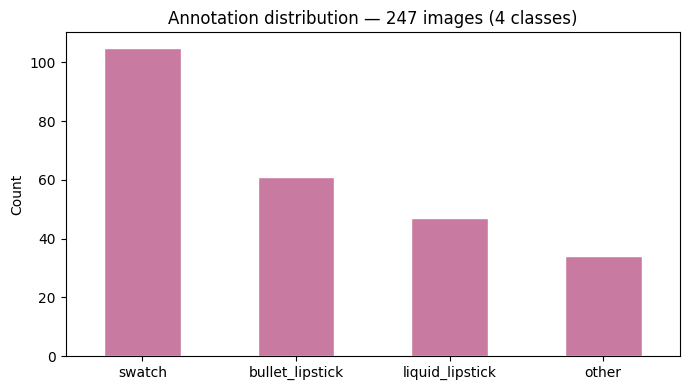

In [157]:
fig, ax = plt.subplots(figsize=(7, 4))
labels_df['label'].value_counts().plot(kind='bar', ax=ax, color='#c97aa0', edgecolor='white')
ax.set_title('Annotation distribution — 247 images (4 classes)')
ax.set_xlabel('')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## 2. Stage 1: Product Type Classifier

ResNet-18 fine-tuned on the four container classes.
- Phase 1 (5 epochs): backbone frozen, train head only
- Phase 2 (15 epochs): full fine-tune with lower LR

Weighted cross-entropy loss to compensate for class imbalance (`other` = 34, `swatch` = 105).

In [158]:
IMG_SIZE_CLS = 224

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE_CLS, IMG_SIZE_CLS)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE_CLS, IMG_SIZE_CLS)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class ProductDataset(Dataset):
    def __init__(self, df, transform):
        # drop rows where the image can't be found on disk
        self.df = df[df['img_name_disk'].notna()].reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(find_image(row['img_name_disk'])).convert('RGB')
        return self.transform(img), CLASSES.index(row['label'])

In [159]:
def build_classifier(num_classes=4, pretrained=True):
    weights = models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
    m = models.resnet18(weights=weights)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

counts = labels_df['label'].value_counts()
total  = len(labels_df)
class_weights = torch.tensor(
    [total / (len(CLASSES) * counts[c]) for c in CLASSES], dtype=torch.float
)
print('Class weights:', {c: round(w, 3) for c, w in zip(CLASSES, class_weights.tolist())})

Class weights: {'bullet_lipstick': 1.012, 'liquid_lipstick': 1.314, 'other': 1.816, 'swatch': 0.588}


In [160]:
def run_epoch(model, loader, criterion, optimizer, device, train=True):
    model.train() if train else model.eval()
    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            if train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item() * len(y)
            correct    += (logits.argmax(1) == y).sum().item()
            n          += len(y)
    return total_loss / n, correct / n

def train_classifier(model, train_ds, val_ds, device, ckpt_path):
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=32, num_workers=0)

    # Phase 1: freeze backbone
    for p in model.parameters():
        p.requires_grad = False
    for p in model.fc.parameters():
        p.requires_grad = True
    opt = torch.optim.Adam(model.fc.parameters(), lr=1e-3)
    print('Phase 1 — head only (5 epochs)')
    for epoch in range(5):
        _, tr_acc = run_epoch(model, train_loader, criterion, opt, device)
        _, va_acc = run_epoch(model, val_loader,   criterion, opt, device, train=False)
        print(f'  {epoch+1:2d}: train={tr_acc:.3f}  val={va_acc:.3f}')

    # Phase 2: fine-tune all
    for p in model.parameters():
        p.requires_grad = True
    opt = torch.optim.Adam(model.parameters(), lr=1e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(opt, step_size=5, gamma=0.1)
    best_val_acc = 0.0
    print('Phase 2 — fine-tune all (15 epochs)')
    for epoch in range(15):
        _, tr_acc = run_epoch(model, train_loader, criterion, opt, device)
        _, va_acc = run_epoch(model, val_loader,   criterion, opt, device, train=False)
        scheduler.step()
        print(f'  {epoch+1:2d}: train={tr_acc:.3f}  val={va_acc:.3f}')
        if va_acc > best_val_acc:
            best_val_acc = va_acc
            torch.save({'model_state_dict': model.state_dict(), 'classes': CLASSES}, ckpt_path)
    print(f'\nBest val acc: {best_val_acc:.3f}  →  {ckpt_path}')

In [161]:
# Split strategy:
# - annotation_sample_closed images (40 oversampled closed class) → always in train
# - everything else → random 80/20 stratified split
ann_closed_files = set(os.listdir(IMG_CLOSED))

force_train = labels_df[labels_df['img_name_disk'].isin(ann_closed_files)]
to_split    = labels_df[~labels_df['img_name_disk'].isin(ann_closed_files) & labels_df['img_name_disk'].notna()]

train_rest, val_df = train_test_split(
    to_split, test_size=0.2, stratify=to_split['label'], random_state=42
)
train_df = pd.concat([force_train, train_rest]).reset_index(drop=True)

print(f'Train: {len(train_df)}  ({len(force_train)} forced closed-addition + {len(train_rest)} random)')
print(f'Val:   {len(val_df)}')
print('\nTrain label distribution:')
print(train_df['label'].value_counts().to_string())
print('\nVal label distribution:')
print(val_df['label'].value_counts().to_string())

clf = build_classifier(num_classes=len(CLASSES)).to(DEVICE)
clf_ckpt = os.path.join(MODELS_DIR, 'resnet18_classifier.pth')
train_classifier(clf, ProductDataset(train_df, train_tf), ProductDataset(val_df, val_tf), DEVICE, clf_ckpt)

Train: 162  (20 forced closed-addition + 142 random)
Val:   36

Train label distribution:
label
swatch             72
bullet_lipstick    44
liquid_lipstick    31
other              15

Val label distribution:
label
swatch             17
bullet_lipstick    11
liquid_lipstick     7
other               1
Phase 1 — head only (5 epochs)
   1: train=0.309  val=0.361
   2: train=0.340  val=0.444
   3: train=0.654  val=0.694
   4: train=0.698  val=0.778
   5: train=0.710  val=0.917
Phase 2 — fine-tune all (15 epochs)
   1: train=0.920  val=0.944
   2: train=0.969  val=0.944
   3: train=0.994  val=0.944
   4: train=0.994  val=0.972
   5: train=1.000  val=0.972
   6: train=1.000  val=0.972
   7: train=0.988  val=0.944
   8: train=0.994  val=0.944
   9: train=1.000  val=0.972
  10: train=1.000  val=0.944
  11: train=0.988  val=0.944
  12: train=0.994  val=0.972
  13: train=0.994  val=0.972
  14: train=0.988  val=0.972
  15: train=0.988  val=0.972

Best val acc: 0.972  →  /Users/connie/dev/lipstic

                 precision    recall  f1-score   support

bullet_lipstick       0.92      1.00      0.96        11
liquid_lipstick       1.00      0.86      0.92         7
          other       1.00      1.00      1.00         1
         swatch       1.00      1.00      1.00        17

       accuracy                           0.97        36
      macro avg       0.98      0.96      0.97        36
   weighted avg       0.97      0.97      0.97        36



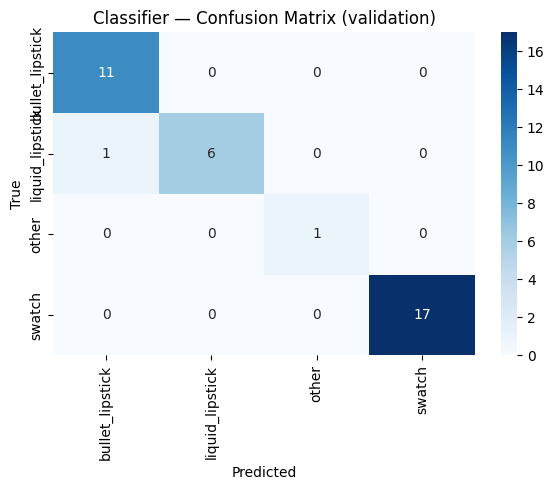

In [162]:
# Load best checkpoint and evaluate on validation set
ckpt = torch.load(clf_ckpt, map_location=DEVICE)
clf.load_state_dict(ckpt['model_state_dict'])
clf.eval()

preds, targets = [], []
with torch.no_grad():
    for x, y in DataLoader(ProductDataset(val_df, val_tf), batch_size=32):
        preds.extend(clf(x.to(DEVICE)).argmax(1).cpu().tolist())
        targets.extend(y.tolist())

print(classification_report(targets, preds, target_names=CLASSES))

cm = confusion_matrix(targets, preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES,
            cmap='Blues', ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Classifier — Confusion Matrix (validation)')
plt.tight_layout(); plt.show()

## 3. Stage 2: Color Region Segmenter

U-Net with ResNet-18 encoder (pretrained on ImageNet) trained on `bullet_lipstick` + `liquid_lipstick` images only.
Input: 256×256 RGB.  Output: binary mask (1 = color region).

Evaluated with IoU (Intersection over Union) on the validation split.

In [163]:
IMG_SIZE_SEG = 256

seg_img_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE_SEG, IMG_SIZE_SEG)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
seg_mask_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE_SEG, IMG_SIZE_SEG),
                      interpolation=transforms.InterpolationMode.NEAREST),
    transforms.ToTensor(),
])

SEG_CLASSES = {'bullet_lipstick', 'liquid_lipstick'}

class SegDataset(Dataset):
    def __init__(self, df):
        self.df = df[df['label'].isin(SEG_CLASSES) & df['img_name_disk'].notna()].reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img  = Image.open(find_image(row['img_name_disk'])).convert('RGB')
        mp   = row['mask_path']
        mask = Image.open(mp).convert('L') if os.path.exists(mp) else Image.new('L', img.size, 0)
        return seg_img_tf(img), (seg_mask_tf(mask) > 0.5).float()

In [164]:
def build_segmenter():
    return smp.Unet(
        encoder_name='resnet18',
        encoder_weights='imagenet',
        in_channels=3,
        classes=1,
    )

def batch_iou(logits, masks, threshold=0.5):
    pred = (torch.sigmoid(logits) > threshold).float()
    inter = (pred * masks).sum(dim=(1, 2, 3))
    union = pred.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3)) - inter
    return (inter / (union + 1e-6)).mean().item()

In [165]:
seg_train_df, seg_val_df = train_test_split(
    labels_df[labels_df['label'].isin(SEG_CLASSES)],
    test_size=0.2, stratify=labels_df[labels_df['label'].isin(SEG_CLASSES)]['label'],
    random_state=42
)
seg_train_ds = SegDataset(seg_train_df)
seg_val_ds   = SegDataset(seg_val_df)
print(f'Seg train: {len(seg_train_ds)}  val: {len(seg_val_ds)}')

seg = build_segmenter().to(DEVICE)
criterion_seg = nn.BCEWithLogitsLoss()
opt_seg       = torch.optim.Adam(seg.parameters(), lr=1e-4)
seg_ckpt      = os.path.join(MODELS_DIR, 'unet_segmenter.pth')

best_iou = 0.0
for epoch in range(20):
    seg.train()
    for imgs, masks in DataLoader(seg_train_ds, batch_size=16, shuffle=True, num_workers=0):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        loss = criterion_seg(seg(imgs), masks)
        opt_seg.zero_grad(); loss.backward(); opt_seg.step()

    seg.eval()
    val_ious = []
    with torch.no_grad():
        for imgs, masks in DataLoader(seg_val_ds, batch_size=16, num_workers=0):
            val_ious.append(batch_iou(seg(imgs.to(DEVICE)), masks.to(DEVICE)))
    mean_iou = np.mean(val_ious)
    print(f'epoch {epoch+1:2d}: IoU={mean_iou:.4f}')
    if mean_iou > best_iou:
        best_iou = mean_iou
        torch.save({'model_state_dict': seg.state_dict()}, seg_ckpt)

print(f'\nBest IoU: {best_iou:.4f}  →  {seg_ckpt}')


Seg train: 74  val: 19
epoch  1: IoU=0.0333
epoch  2: IoU=0.0648
epoch  3: IoU=0.0870
epoch  4: IoU=0.1207
epoch  5: IoU=0.1718
epoch  6: IoU=0.2314
epoch  7: IoU=0.2987
epoch  8: IoU=0.3859
epoch  9: IoU=0.4576
epoch 10: IoU=0.5016
epoch 11: IoU=0.5109
epoch 12: IoU=0.5307
epoch 13: IoU=0.5404
epoch 14: IoU=0.5449
epoch 15: IoU=0.5496
epoch 16: IoU=0.5614
epoch 17: IoU=0.5536
epoch 18: IoU=0.5576
epoch 19: IoU=0.6040
epoch 20: IoU=0.5869

Best IoU: 0.6040  →  /Users/connie/dev/lipstick_color_extraction/models/unet_segmenter.pth


**Note: scheduler experiment (worse, not used):** Adding `ReduceLROnPlateau` (factor=0.3, patience=5) and extending to 30 epochs produced lower validation IoU than the simple 20-epoch fixed-LR run above. The bottleneck is data size (74 training images), not the learning rate schedule. The path to better segmentation is more annotated images, not longer training.

Visual check on a sample of 4 validation images: original image, hand-drawn Label Studio mask (ground truth), and U-Net prediction side by side. Confirms mask alignment before using predictions for color extraction.

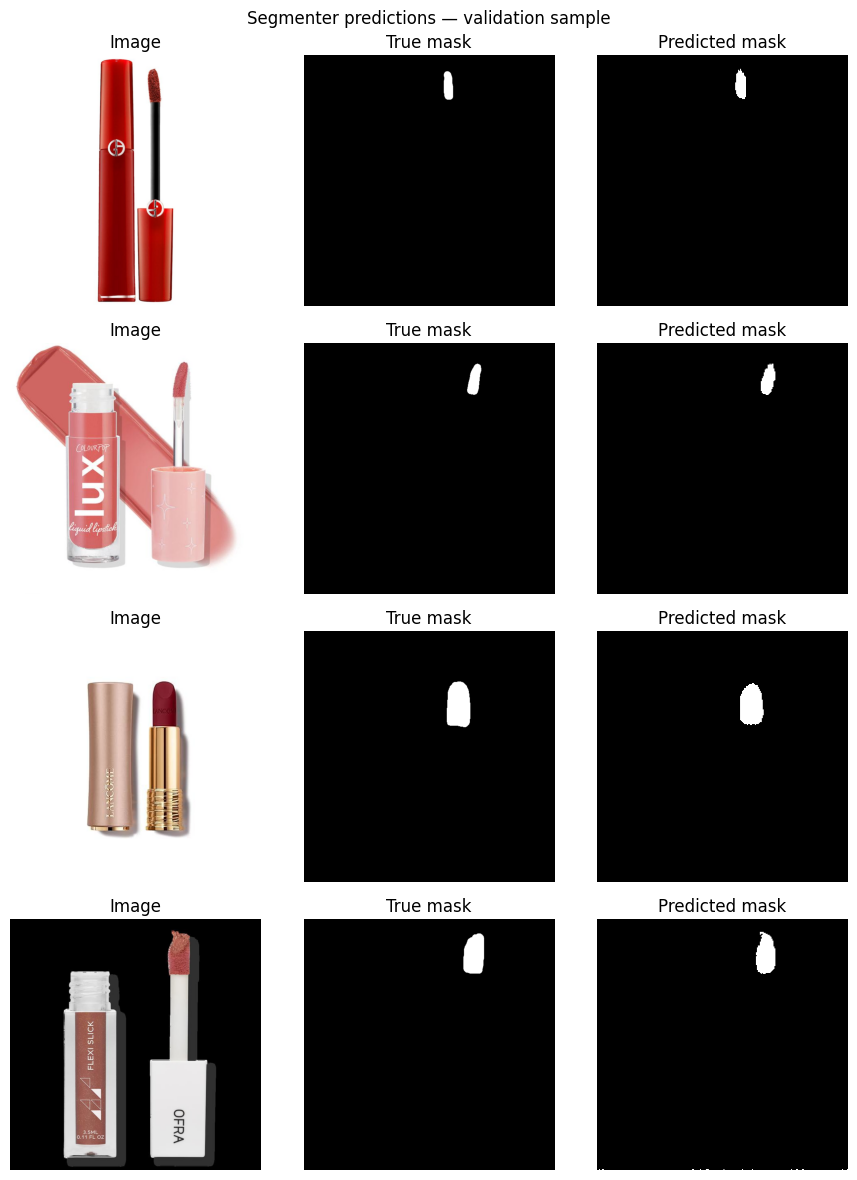

In [166]:
# Visualise a few val predictions
ckpt_seg = torch.load(seg_ckpt, map_location=DEVICE)
seg.load_state_dict(ckpt_seg['model_state_dict'])
seg.eval()

sample = seg_val_df.head(4).reset_index(drop=True)
fig, axes = plt.subplots(4, 3, figsize=(9, 12))
for i, row in sample.iterrows():
    img_path = find_image(row['img_name'])
    img = Image.open(img_path).convert('RGB')
    x   = seg_img_tf(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        pred_mask = (torch.sigmoid(seg(x)) > 0.5).squeeze().cpu().numpy()
    true_mask = np.array(Image.open(row['mask_path']).convert('L')) if os.path.exists(row['mask_path']) else np.zeros((img.size[1], img.size[0]))
    axes[i, 0].imshow(img); axes[i, 0].set_title('Image')
    axes[i, 1].imshow(true_mask, cmap='gray'); axes[i, 1].set_title('True mask')
    axes[i, 2].imshow(pred_mask, cmap='gray'); axes[i, 2].set_title('Predicted mask')
    for ax in axes[i]: ax.axis('off')
plt.suptitle('Segmenter predictions — validation sample')
plt.tight_layout()
plt.show()

### Stage 2b: Color Region Segmenter for `other` (Transparent Containers)

`other` images (closed/transparent containers) have hand-drawn masks highlighting the visible color through the packaging: the same annotation format as bullet/liquid. A separate U-Net is trained on these images so color can be extracted the same way as the other classes.

Same architecture and training procedure as Stage 2a; saved to `models/unet_segmenter_other.pth`.

In [172]:
import random

class SegDatasetAny(Dataset):
    """Like SegDataset but accepts any label subset, with optional synchronized augmentation."""
    def __init__(self, df, augment=False):
        self.df      = df[df['img_name_disk'].notna()].reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        img  = Image.open(find_image(row['img_name_disk'])).convert('RGB')
        mp   = row['mask_path']
        mask = Image.open(mp).convert('L') if os.path.exists(mp) else Image.new('L', img.size, 0)

        if self.augment:
            if random.random() > 0.5:
                img  = img.transpose(Image.FLIP_LEFT_RIGHT)
                mask = mask.transpose(Image.FLIP_LEFT_RIGHT)
            if random.random() > 0.5:
                img  = img.transpose(Image.FLIP_TOP_BOTTOM)
                mask = mask.transpose(Image.FLIP_TOP_BOTTOM)
            angle = random.uniform(-15, 15)
            img  = img.rotate(angle)
            mask = mask.rotate(angle)

        return seg_img_tf(img), (seg_mask_tf(mask) > 0.5).float()

other_df = labels_df[labels_df['label'] == 'other'].reset_index(drop=True)
seg_other_train_df, seg_other_val_df = train_test_split(
    other_df, test_size=0.2, random_state=42
)
seg_other_train_ds = SegDatasetAny(seg_other_train_df, augment=True)
seg_other_val_ds   = SegDatasetAny(seg_other_val_df,   augment=False)
print(f'Other seg — train: {len(seg_other_train_ds)}  val: {len(seg_other_val_ds)}')

# Warm-start from bullet/liquid segmenter — encoder + decoder already tuned to lipstick images
seg_other = build_segmenter().to(DEVICE)
seg_other.load_state_dict(torch.load(seg_ckpt, map_location=DEVICE)['model_state_dict'])
print('Warm-started from unet_segmenter.pth')

crit_seg_other = nn.BCEWithLogitsLoss()
opt_seg_other  = torch.optim.Adam(seg_other.parameters(), lr=1e-4)
seg_other_ckpt = os.path.join(MODELS_DIR, 'unet_segmenter_other.pth')

best_iou_other = 0.0
for epoch in range(20):
    seg_other.train()
    for imgs, masks in DataLoader(seg_other_train_ds, batch_size=16, shuffle=True, num_workers=0):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        loss = crit_seg_other(seg_other(imgs), masks)
        opt_seg_other.zero_grad(); loss.backward(); opt_seg_other.step()

    seg_other.eval()
    val_ious = []
    with torch.no_grad():
        for imgs, masks in DataLoader(seg_other_val_ds, batch_size=16, num_workers=0):
            val_ious.append(batch_iou(seg_other(imgs.to(DEVICE)), masks.to(DEVICE)))
    mean_iou = np.mean(val_ious)
    print(f'epoch {epoch+1:2d}: IoU={mean_iou:.4f}')
    if mean_iou > best_iou_other:
        best_iou_other = mean_iou
        torch.save({'model_state_dict': seg_other.state_dict()}, seg_other_ckpt)

print(f'\nBest IoU: {best_iou_other:.4f}  →  {seg_other_ckpt}')

ckpt_seg_other = torch.load(seg_other_ckpt, map_location=DEVICE)
seg_other.load_state_dict(ckpt_seg_other['model_state_dict'])
seg_other.eval()
print('seg_other loaded from best checkpoint')

Other seg — train: 11  val: 5
Warm-started from unet_segmenter.pth
epoch  1: IoU=0.0011
epoch  2: IoU=0.1632
epoch  3: IoU=0.2310
epoch  4: IoU=0.4371
epoch  5: IoU=0.5634
epoch  6: IoU=0.6499
epoch  7: IoU=0.6903
epoch  8: IoU=0.6911
epoch  9: IoU=0.7123
epoch 10: IoU=0.7262
epoch 11: IoU=0.7607
epoch 12: IoU=0.8088
epoch 13: IoU=0.8440
epoch 14: IoU=0.8611
epoch 15: IoU=0.8680
epoch 16: IoU=0.8786
epoch 17: IoU=0.8843
epoch 18: IoU=0.8849
epoch 19: IoU=0.8864
epoch 20: IoU=0.8904

Best IoU: 0.8904  →  /Users/connie/dev/lipstick_color_extraction/models/unet_segmenter_other.pth
seg_other loaded from best checkpoint


Initial training on `other` images (ImageNet weights, no augmentation) produced loose, imprecise masks: the model found the general region but failed to follow the color boundary tightly. Two changes improved this:

1. **Warm start from `unet_segmenter.pth`**: instead of starting from generic ImageNet weights, the model is initialized with the bullet/liquid segmenter's weights. Both encoder and decoder have already learned what a lipstick color-region mask looks like, giving a much better starting point.
2. **Synchronized augmentation**: horizontal flip, vertical flip, and ±15° rotation are applied identically to the image and mask during training. With only ~27 training images, this significantly increases the effective diversity seen by the model.

The validation sample below shows the predicted mask aligning tightly with the ground-truth mask after these changes.

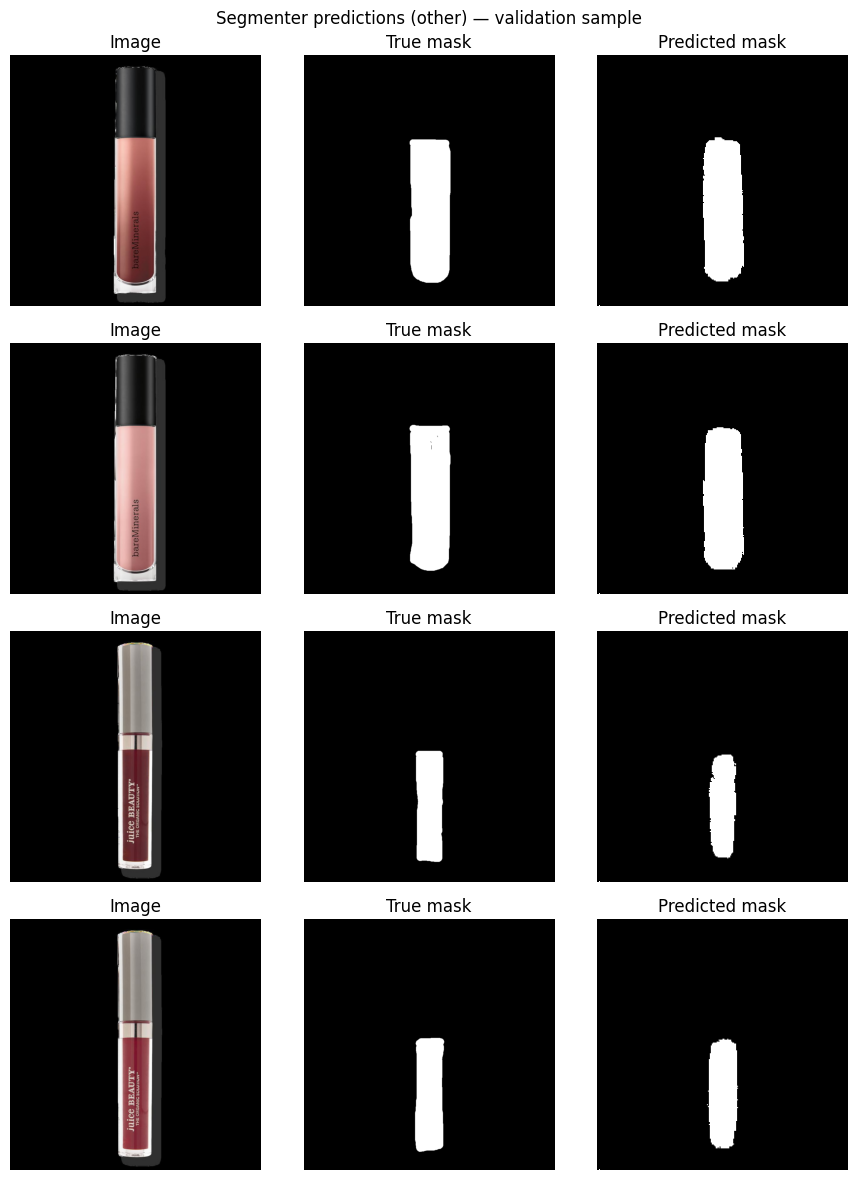

In [173]:
sample_other = seg_other_val_df.dropna(subset=['img_name_disk']).head(4).reset_index(drop=True)
fig, axes = plt.subplots(4, 3, figsize=(9, 12))
for i, row in sample_other.iterrows():
    img_path = find_image(row['img_name_disk'])
    img = Image.open(img_path).convert('RGB')
    x   = seg_img_tf(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        pred_mask = (torch.sigmoid(seg_other(x)) > 0.5).squeeze().cpu().numpy()
    true_mask = np.array(Image.open(row['mask_path']).convert('L')) if os.path.exists(row['mask_path']) else np.zeros((img.size[1], img.size[0]))
    axes[i, 0].imshow(img); axes[i, 0].set_title('Image')
    axes[i, 1].imshow(true_mask, cmap='gray'); axes[i, 1].set_title('True mask')
    axes[i, 2].imshow(pred_mask, cmap='gray'); axes[i, 2].set_title('Predicted mask')
    for ax in axes[i]: ax.axis('off')
plt.suptitle('Segmenter predictions (other) — validation sample')
plt.tight_layout()
plt.show()

## 4. Routing & Color Extraction

Given an image and its true label (using ground-truth type here to isolate color extraction quality from classification errors):
- `swatch` → median LAB after removing white (L > 95) and black (L < 5) background pixels
- `bullet_lipstick` / `liquid_lipstick` → U-Net mask → **median** LAB from masked pixels
- `other` → separate U-Net mask → **dominant cluster** LAB from masked pixels

Extraction strategy per type was selected by comparing five strategies in Section 6: median is best for bullet/liquid/swatch, while dominant cluster outperforms for `other` (transparent containers where the mask captures a mix of container and color pixels: clustering isolates the true color region).

In production the routing uses the classifier output instead of the true label.

In [196]:
from sklearn.cluster import KMeans

def extract_swatch_color(img_rgb):
    img_lab = skcolor.rgb2lab(img_rgb / 255.0)
    L = img_lab[:, :, 0]
    fg = (L > 5) & (L < 95)
    if fg.sum() == 0:
        fg = np.ones_like(L, dtype=bool)
    return np.median(img_lab[fg], axis=0)

def extract_masked_color(img_rgb, mask_arr):
    img_lab = skcolor.rgb2lab(img_rgb / 255.0)
    pixels  = img_lab[mask_arr == 1]
    if len(pixels) == 0:
        return np.array([np.nan, np.nan, np.nan])
    return np.median(pixels, axis=0)

def extract_dominant_cluster_color(img_rgb, mask_arr, k=3):
    """LAB centroid of the largest K-means cluster within the masked region.
    Outperforms median for `other` (transparent containers) where the mask
    often captures mixed background pixels alongside the true color region.
    """
    img_lab = skcolor.rgb2lab(img_rgb / 255.0)
    pixels  = img_lab[mask_arr == 1]
    if len(pixels) == 0:
        return np.full(3, np.nan)
    if len(pixels) < k:
        return np.median(pixels, axis=0)
    km = KMeans(n_clusters=k, random_state=SEED, n_init='auto')
    labels = km.fit_predict(pixels)
    biggest = np.bincount(labels).argmax()
    return km.cluster_centers_[biggest]

def predict_mask(model, img_path, device, threshold=0.5):
    img    = Image.open(img_path).convert('RGB')
    orig_w, orig_h = img.size
    x      = seg_img_tf(img).unsqueeze(0).to(device)
    with torch.no_grad():
        prob = torch.sigmoid(model(x)).squeeze().cpu().numpy()
    mask = (prob > threshold).astype(np.uint8)
    return np.array(Image.fromarray(mask * 255).resize((orig_w, orig_h), Image.NEAREST)) // 255

In [197]:
clf.eval()
seg.eval()
seg_other.eval()

results = []
for _, row in labels_df.iterrows():
    if pd.isna(row['img_name_disk']):
        continue
    img_path = find_image(row['img_name_disk'])
    if img_path is None:
        continue
    label = row['label']
    img   = np.array(Image.open(img_path).convert('RGB'))

    if label == 'swatch':
        lab = extract_swatch_color(img)
    elif label in SEG_CLASSES:
        mask = predict_mask(seg, img_path, DEVICE)
        lab  = extract_masked_color(img, mask)
    else:  # other → dominant cluster (best strategy per Section 6)
        mask = predict_mask(seg_other, img_path, DEVICE)
        lab  = extract_dominant_cluster_color(img, mask)

    results.append({
        'img_name':      row['img_name'],
        'img_name_disk': row['img_name_disk'],
        'label':         label,
        'pred_L':        lab[0], 'pred_a': lab[1], 'pred_b': lab[2],
        'true_L':        row.get('true_L', np.nan),
        'true_a':        row.get('true_a', np.nan),
        'true_b':        row.get('true_b', np.nan),
    })

predictions = pd.DataFrame(results)
print(predictions.head())
print(f'\n{predictions["pred_L"].notna().sum()} images with extracted color')

                                            img_name  \
0  lipstick__aboutface__paintit_matte_lip_color__...   
1  lipstick__anastasia_beverly_hills__liquid_lips...   
2  lipstick__anastasia_beverly_hills__liquid_lips...   
3  lipstick__anastasia_beverly_hills__matte_lipst...   
4  lipstick__anastasia_beverly_hills__matte_lipst...   

                                       img_name_disk            label  \
0  lipstick__aboutface__paintit_matte_lip_color__...           swatch   
1  lipstick__anastasia_beverly_hills__liquid_lips...           swatch   
2  lipstick__anastasia_beverly_hills__liquid_lips...  liquid_lipstick   
3  lipstick__anastasia_beverly_hills__matte_lipst...  bullet_lipstick   
4  lipstick__anastasia_beverly_hills__matte_lipst...           swatch   

      pred_L     pred_a     pred_b     true_L     true_a     true_b  
0  12.250030  -0.000513   0.000973   2.677718  -0.000170   0.000322  
1  49.738762  31.926315  11.752330  42.008854  33.801550  12.567961  
2  31.501913  

## 5. Evaluation: Delta E vs Ground Truth

Delta E CIE 2000 between predicted LAB and the ground-truth LAB from manual crops.
Compared per container type. Lower is better (human threshold ≈ 1–2 JND).

                 mean  median    std  count
label                                      
bullet_lipstick  3.87    1.96   5.56     53
liquid_lipstick  6.57    2.41  15.37     34
other            2.22    2.03   1.33      4
swatch           3.15    1.12   7.71     84


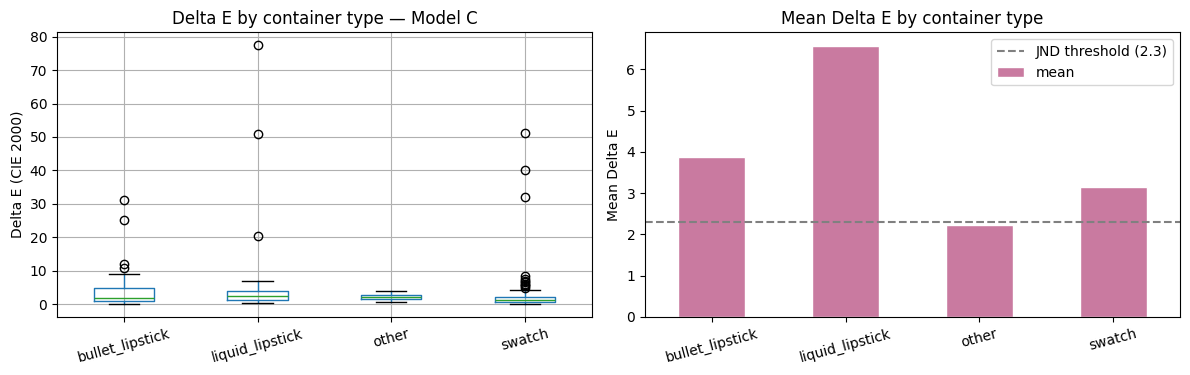

In [198]:
import numpy as np
if not hasattr(np, 'asscalar'):
    np.asscalar = lambda a: a.item()  # removed in NumPy 1.24, colormath still uses it

from colormath.color_objects import LabColor
from colormath.color_diff import delta_e_cie2000

def delta_e(pred_lab, true_lab):
    return delta_e_cie2000(LabColor(*pred_lab), LabColor(*true_lab))

eval_df = predictions.dropna(subset=['true_L', 'pred_L']).copy()
eval_df['delta_e'] = eval_df.apply(
    lambda r: delta_e(
        [r['pred_L'], r['pred_a'], r['pred_b']],
        [r['true_L'], r['true_a'], r['true_b']]
    ), axis=1
)

summary = eval_df.groupby('label')['delta_e'].agg(['mean', 'median', 'std', 'count'])
print(summary.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

eval_df.boxplot(column='delta_e', by='label', ax=axes[0])
axes[0].set_title('Delta E by container type — Model C')
axes[0].set_xlabel(''); axes[0].set_ylabel('Delta E (CIE 2000)')
plt.sca(axes[0]); plt.xticks(rotation=15)

summary['mean'].plot(kind='bar', ax=axes[1], color='#c97aa0', edgecolor='white')
axes[1].set_title('Mean Delta E by container type')
axes[1].set_xlabel(''); axes[1].set_ylabel('Mean Delta E')
axes[1].tick_params(axis='x', rotation=15)
axes[1].axhline(2.3, color='gray', linestyle='--', label='JND threshold (2.3)')
axes[1].legend()

plt.suptitle('')
plt.tight_layout()
plt.show()

Delta E CIE 2000 — tier breakdown by container type (median strategy)



,n,≤ 2.3 (great),2.3 – 5 (acceptable),> 5 (poor)
category,,,,
bullet_lipstick,53,27 (51%),15 (28%),11 (21%)
liquid_lipstick,34,16 (47%),14 (41%),4 (12%)
other,4,3 (75%),1 (25%),0 (0%)
swatch,84,64 (76%),10 (12%),10 (12%)
ALL,175,110 (63%),40 (23%),25 (14%)


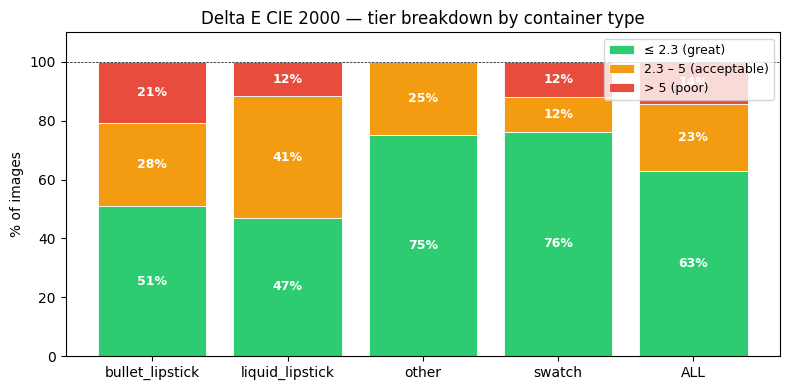

In [199]:
# Delta E tier breakdown per container type
# Three tiers: ≤2.3 (great — within JND), 2.3–5 (acceptable), >5 (poor)

def tier_breakdown(df, group_col='label', de_col='delta_e'):
    rows = []
    for label, grp in df.groupby(group_col):
        n = len(grp)
        great      = (grp[de_col] <= 2.3).sum()
        acceptable = ((grp[de_col] > 2.3) & (grp[de_col] <= 5)).sum()
        poor       = (grp[de_col] > 5).sum()
        rows.append({
            'category':           label,
            'n':                  n,
            '≤ 2.3 (great)':      f"{great} ({100*great/n:.0f}%)",
            '2.3 – 5 (acceptable)': f"{acceptable} ({100*acceptable/n:.0f}%)",
            '> 5 (poor)':         f"{poor} ({100*poor/n:.0f}%)",
            '_great_pct':         100 * great / n,
            '_ok_pct':            100 * acceptable / n,
            '_poor_pct':          100 * poor / n,
        })
    # Overall row
    n = len(df)
    great      = (df[de_col] <= 2.3).sum()
    acceptable = ((df[de_col] > 2.3) & (df[de_col] <= 5)).sum()
    poor       = (df[de_col] > 5).sum()
    rows.append({
        'category':           'ALL',
        'n':                  n,
        '≤ 2.3 (great)':      f"{great} ({100*great/n:.0f}%)",
        '2.3 – 5 (acceptable)': f"{acceptable} ({100*acceptable/n:.0f}%)",
        '> 5 (poor)':         f"{poor} ({100*poor/n:.0f}%)",
        '_great_pct':         100 * great / n,
        '_ok_pct':            100 * acceptable / n,
        '_poor_pct':          100 * poor / n,
    })
    return pd.DataFrame(rows)

bd = tier_breakdown(eval_df)
display_cols = ['category', 'n', '≤ 2.3 (great)', '2.3 – 5 (acceptable)', '> 5 (poor)']
print("Delta E CIE 2000 — tier breakdown by container type (median strategy)\n")
display(bd[display_cols].set_index('category'))

# Stacked bar chart
categories = bd['category'].tolist()
pct_great  = bd['_great_pct'].values
pct_ok     = bd['_ok_pct'].values
pct_poor   = bd['_poor_pct'].values

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#2ecc71', '#f39c12', '#e74c3c']
labels_tiers = ['≤ 2.3 (great)', '2.3 – 5 (acceptable)', '> 5 (poor)']
bottoms = np.zeros(len(categories))
for pct, color, tier_label in zip([pct_great, pct_ok, pct_poor], colors, labels_tiers):
    bars = ax.bar(categories, pct, bottom=bottoms, color=color,
                  label=tier_label, edgecolor='white', linewidth=0.6)
    for bar, val in zip(bars, pct):
        if val >= 7:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + bar.get_height() / 2,
                    f'{val:.0f}%', ha='center', va='center',
                    fontsize=9, color='white', fontweight='bold')
    bottoms += pct

ax.set_ylabel('% of images')
ax.set_ylim(0, 110)
ax.set_title('Delta E CIE 2000 — tier breakdown by container type')
ax.legend(loc='upper right', fontsize=9)
ax.axhline(100, color='black', linewidth=0.5, linestyle='--')
plt.tight_layout()
plt.show()


The 12 images with the highest Delta E are shown below to investigate failure patterns. For each case, the product image is shown with the mask overlay (bullet/liquid types), and the predicted color (left swatch) is placed directly next to the ground-truth color (right swatch) for comparison.

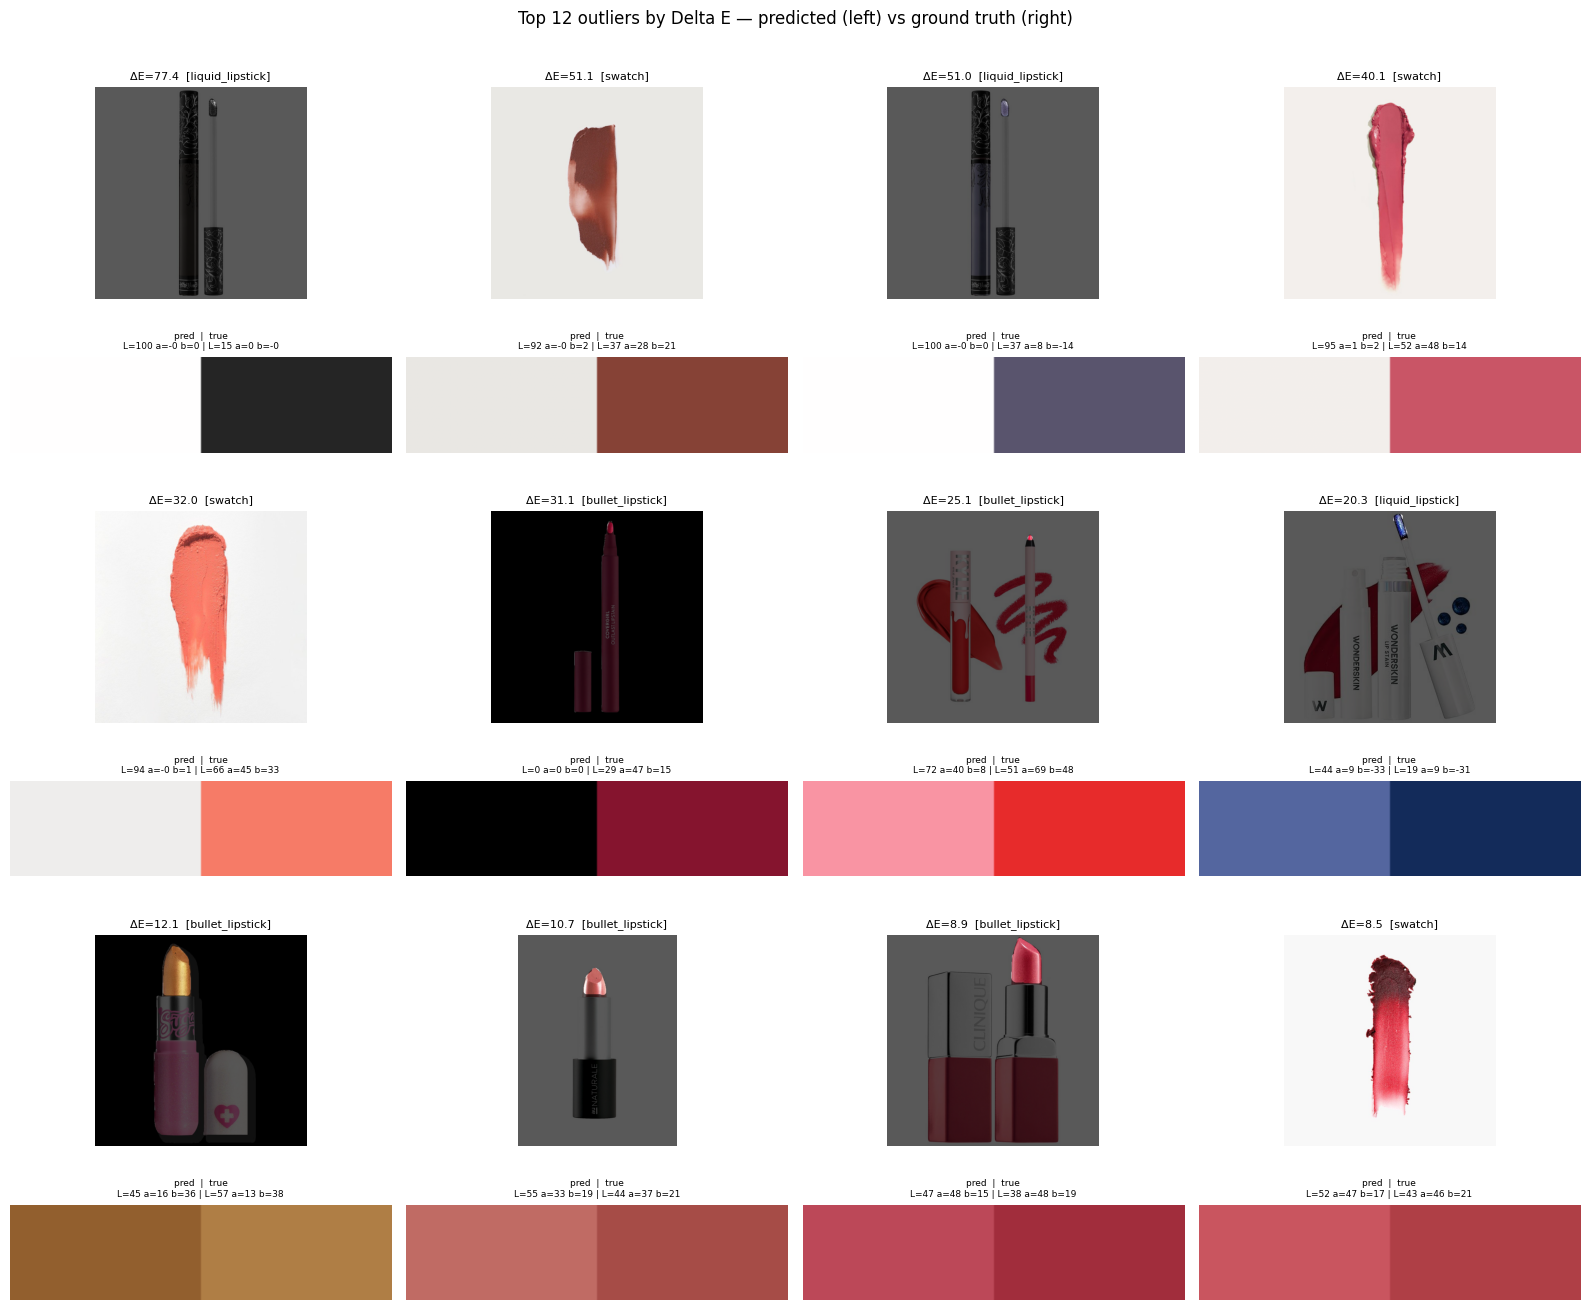

In [200]:
def lab_to_rgb_swatch(L, a, b, size=(80, 40)):
    """Convert a single LAB value to an RGB swatch image."""
    lab = np.array([[[L, a, b]]], dtype=np.float64)
    rgb = skcolor.lab2rgb(lab).clip(0, 1)
    swatch = np.ones((size[1], size[0], 3), dtype=np.float32) * rgb[0, 0]
    return swatch

n_outliers = 12
outliers = eval_df.nlargest(n_outliers, 'delta_e').reset_index(drop=True)

ncols = 4
nrows = int(np.ceil(n_outliers / ncols))
fig, axes = plt.subplots(nrows * 2, ncols, figsize=(ncols * 4, nrows * 4.5))
axes = axes.reshape(nrows * 2, ncols)

for i, row in outliers.iterrows():
    r, c = (i // ncols) * 2, i % ncols

    ax_img = axes[r, c]
    img_path = find_image(row['img_name_disk'])
    img = np.array(Image.open(img_path).convert('RGB'))
    ax_img.imshow(img)

    if row['label'] in SEG_CLASSES:
        mask_path = os.path.join(MASKS_DIR, os.path.splitext(row['img_name'])[0] + '.png')
        if os.path.exists(mask_path):
            mask = np.array(Image.open(mask_path).convert('L'))
            overlay = img.copy().astype(float)
            overlay[mask == 0] *= 0.35
            ax_img.imshow(overlay.astype(np.uint8))

    ax_img.set_title(f"ΔE={row['delta_e']:.1f}  [{row['label']}]", fontsize=8)
    ax_img.axis('off')

    ax_color = axes[r + 1, c]
    pred_swatch = lab_to_rgb_swatch(row['pred_L'], row['pred_a'], row['pred_b'])
    true_swatch = lab_to_rgb_swatch(row['true_L'], row['true_a'], row['true_b'])
    ax_color.imshow(np.concatenate([pred_swatch, true_swatch], axis=1))
    ax_color.set_title(
        f"pred  |  true\n"
        f"L={row['pred_L']:.0f} a={row['pred_a']:.0f} b={row['pred_b']:.0f} | "
        f"L={row['true_L']:.0f} a={row['true_a']:.0f} b={row['true_b']:.0f}",
        fontsize=6.5
    )
    ax_color.axis('off')

for j in range(n_outliers, nrows * ncols):
    r, c = (j // ncols) * 2, j % ncols
    axes[r, c].axis('off')
    axes[r + 1, c].axis('off')

plt.suptitle(f'Top {n_outliers} outliers by Delta E — predicted (left) vs ground truth (right)', y=1.01)
plt.tight_layout()
plt.show()

## 6. Color Extraction Strategy Comparison

Some images have shadows, highlights, or gradients across the masked region.
Here we compare five extraction strategies on the same masked pixels and score each against ground truth with Delta E CIE 2000.

Using the median to extract the color from the identified selection produces the smallers Delta E across all product categories.

In [179]:
from sklearn.cluster import KMeans
from scipy.stats import trim_mean

def get_masked_lab_pixels(img_rgb, mask):
    """Return LAB pixel array for foreground pixels in mask."""
    lab = skcolor.rgb2lab(img_rgb / 255.0)
    pixels = lab[mask == 1]
    return pixels  # shape (N, 3)

def get_swatch_lab_pixels(img_rgb):
    """Return LAB pixels after background removal (for swatch images)."""
    lab = skcolor.rgb2lab(img_rgb / 255.0)
    L = lab[:, :, 0]
    fg = (L > 5) & (L < 95)
    if fg.sum() == 0:
        fg = np.ones_like(L, dtype=bool)
    return lab[fg]

# ── strategy functions ──────────────────────────────────────────────────────

def strat_mean(pixels):
    return np.mean(pixels, axis=0)

def strat_median(pixels):
    return np.median(pixels, axis=0)

def strat_trimmed_mean(pixels, trim=0.10):
    """Drop darkest and brightest `trim` fraction by L, then take mean."""
    L = pixels[:, 0]
    lo, hi = np.quantile(L, trim), np.quantile(L, 1 - trim)
    keep = (L >= lo) & (L <= hi)
    sub = pixels[keep] if keep.sum() > 0 else pixels
    return np.mean(sub, axis=0)

def strat_dominant_cluster(pixels, k=3):
    """K-means with k clusters, return centroid of the largest cluster."""
    if len(pixels) < k:
        return np.mean(pixels, axis=0)
    km = KMeans(n_clusters=k, random_state=SEED, n_init='auto')
    labels = km.fit_predict(pixels)
    biggest = np.bincount(labels).argmax()
    return km.cluster_centers_[biggest]

def strat_shadow_filtered_mean(pixels, chroma_thresh=5.0):
    """Remove near-grey pixels (low chroma = shadows / highlights), then mean.
    Chroma = sqrt(a^2 + b^2).
    """
    chroma = np.sqrt(pixels[:, 1] ** 2 + pixels[:, 2] ** 2)
    keep = chroma >= chroma_thresh
    sub = pixels[keep] if keep.sum() > 0 else pixels
    return np.mean(sub, axis=0)

STRATEGIES = {
    'mean':              strat_mean,
    'median':            strat_median,
    'trimmed_mean_10%':  strat_trimmed_mean,
    'dominant_cluster':  strat_dominant_cluster,
    'shadow_filtered':   strat_shadow_filtered_mean,
}

print('Strategies defined:', list(STRATEGIES.keys()))

Strategies defined: ['mean', 'median', 'trimmed_mean_10%', 'dominant_cluster', 'shadow_filtered']


In [ ]:
seg.eval()
seg_other.eval()

strat_records = []

for _, row in labels_df[labels_df['true_L'].notna() & labels_df['img_name_disk'].notna()].iterrows():
    img_path = find_image(row['img_name_disk'])
    if img_path is None:
        continue
    img_rgb = np.array(Image.open(img_path).convert('RGB'))
    label   = row['label']

    if label == 'swatch':
        pixels = get_swatch_lab_pixels(img_rgb)
    elif label in SEG_CLASSES:
        mask = predict_mask(seg, img_path, DEVICE)
        pixels = get_masked_lab_pixels(img_rgb, mask)
        if len(pixels) == 0:
            continue
    else:  # other
        mask = predict_mask(seg_other, img_path, DEVICE)
        pixels = get_masked_lab_pixels(img_rgb, mask)
        if len(pixels) == 0:
            continue

    rec = {
        'img_name': row['img_name'],
        'label':    label,
        'true_L':   row['true_L'],
        'true_a':   row['true_a'],
        'true_b':   row['true_b'],
    }
    for name, fn in STRATEGIES.items():
        lab = fn(pixels)
        rec[f'{name}_L'] = lab[0]
        rec[f'{name}_a'] = lab[1]
        rec[f'{name}_b'] = lab[2]
    strat_records.append(rec)

strat_df = pd.DataFrame(strat_records)
print(f'{len(strat_df)} images evaluated across {len(STRATEGIES)} strategies')

=== Overall ===
                  mean ΔE  median ΔE
median               3.59       1.56
shadow_filtered      4.00       2.71
trimmed_mean_10%     4.21       2.24
dominant_cluster     4.37       2.29
mean                 5.43       3.69

=== Per container type (mean ΔE) ===
label             bullet_lipstick  liquid_lipstick  swatch
mean                         5.21             7.92    4.56
median                       3.34             5.09    3.15
trimmed_mean_10%             3.70             6.37    3.67
dominant_cluster             4.20             6.63    3.57
shadow_filtered              4.47             4.79    3.39


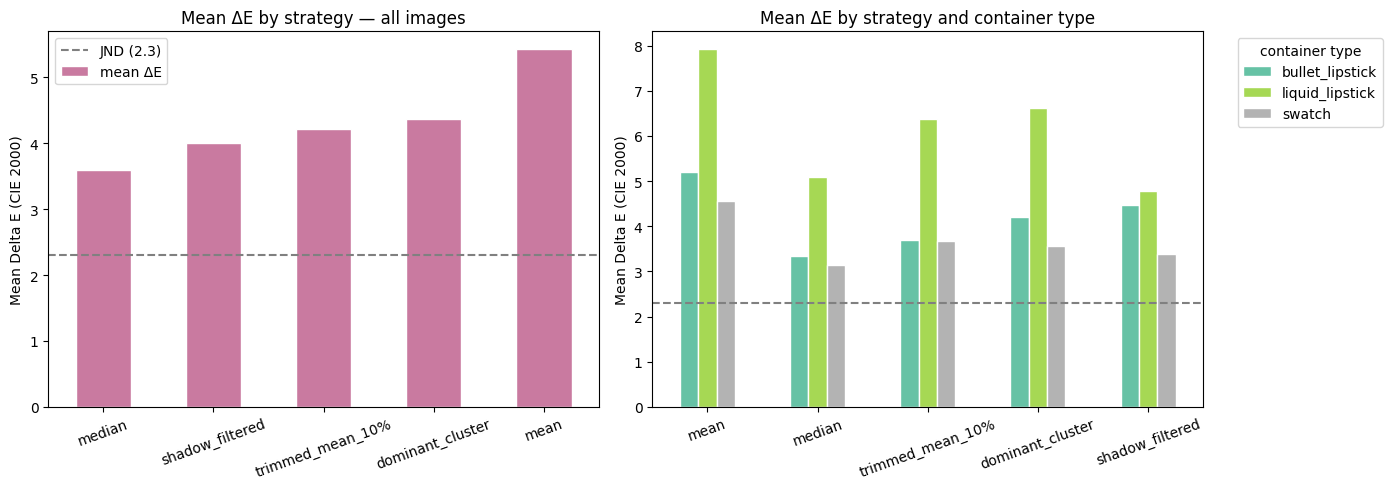

In [ ]:
import numpy as np
if not hasattr(np, 'asscalar'):
    np.asscalar = lambda a: a.item()
from colormath.color_objects import LabColor
from colormath.color_diff import delta_e_cie2000

def de(pred, true):
    return delta_e_cie2000(LabColor(*pred), LabColor(*true))

# Compute Delta E for each strategy
for name in STRATEGIES:
    strat_df[f'de_{name}'] = strat_df.apply(
        lambda r: de(
            [r[f'{name}_L'], r[f'{name}_a'], r[f'{name}_b']],
            [r['true_L'],    r['true_a'],    r['true_b']]
        ), axis=1
    )

de_cols = [f'de_{n}' for n in STRATEGIES]

# overall summary 
overall = strat_df[de_cols].agg(['mean', 'median']).T
overall.index = list(STRATEGIES.keys())
overall.columns = ['mean ΔE', 'median ΔE']
overall = overall.sort_values('mean ΔE')
print('=== Overall ===')
print(overall.round(2))

# per label summary 
print('\n=== Per container type (mean ΔE) ===')
by_label = strat_df.groupby('label')[de_cols].mean().T
by_label.index = list(STRATEGIES.keys())
print(by_label.round(2))

# visualisation 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

overall['mean ΔE'].plot(kind='bar', ax=axes[0], color='#c97aa0', edgecolor='white')
axes[0].axhline(2.3, color='gray', linestyle='--', label='JND (2.3)')
axes[0].set_title('Mean ΔE by strategy — all images')
axes[0].set_ylabel('Mean Delta E (CIE 2000)')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend()

by_label.plot(kind='bar', ax=axes[1], colormap='Set2', edgecolor='white')
axes[1].axhline(2.3, color='gray', linestyle='--')
axes[1].set_title('Mean ΔE by strategy and container type')
axes[1].set_ylabel('Mean Delta E (CIE 2000)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(title='container type', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## 7. Diagnosing Stage 1 Misclassification → Active Learning for the Classifier

The outliers in Section 5 point to a Stage 1 problem: closed-container images are being misclassified as `bullet_lipstick` or `liquid_lipstick`, which routes them through the U-Net and produces a nonsense color prediction.

**Step 1** surfaces this by scoring classifier uncertainty on images outside the training set. Low-confidence predictions: especially images the model splits between `bullet`/`liquid` and `other`: reveal the misclassification pattern.

**Step 2** uses those images as an annotation queue: review, correct the label where wrong, and retrain Stage 1 with the expanded dataset.

In [190]:
# ── Find images outside classifier training/val sets ────────────────────────
clf_known = set(train_df['img_name_disk'].dropna()) | set(val_df['img_name_disk'].dropna())

all_on_disk = {}
for d in IMG_DIRS:
    for fname in os.listdir(d):
        if fname not in all_on_disk:
            all_on_disk[fname] = os.path.join(d, fname)

pool_candidates = [
    {'img_name': name, 'img_path': path}
    for name, path in all_on_disk.items()
    if name not in clf_known
]
print(f'Pool: {len(pool_candidates)} images outside classifier training/val sets')

# ── Score classifier uncertainty and record class probabilities ──────────────
def score_clf_uncertainty(model, img_path, device):
    """Returns (predicted_class, confidence, full softmax prob array)."""
    img = Image.open(img_path).convert('RGB')
    with torch.no_grad():
        probs = torch.softmax(
            model(val_tf(img).unsqueeze(0).to(device)), dim=1
        ).squeeze().cpu().numpy()
    return CLASSES[probs.argmax()], float(probs.max()), probs

clf.eval()
scored = []
for item in pool_candidates:
    try:
        pred_label, conf, probs = score_clf_uncertainty(clf, item['img_path'], DEVICE)
        scored.append({
            **item,
            'pred_label':  pred_label,
            'confidence':  conf,
            'uncertainty': 1 - conf,
            **{f'p_{c}': float(p) for c, p in zip(CLASSES, probs)},
        })
    except Exception:
        continue

pool_clf_df = (
    pd.DataFrame(scored)
    .sort_values('uncertainty', ascending=False)
    .reset_index(drop=True)
)
print(f'\nTop 10 most uncertain classifier predictions:')
print(pool_clf_df[['img_name', 'pred_label', 'confidence']].head(10).to_string(index=False))


Pool: 48 images outside classifier training/val sets

Top 10 most uncertain classifier predictions:
                                                                                                      img_name      pred_label  confidence
                   lipstick__chanel__le_rouge_duo_ultra_tenue_ultrawear_liquid_lip_colour__69_tender_beige.jpg           other    0.499531
                   lipstick__chanel__le_rouge_duo_ultra_tenue_ultrawear_liquid_lip_colour__57_darling_pink.jpg           other    0.510044
                   lipstick__chanel__le_rouge_duo_ultra_tenue_ultrawear_liquid_lip_colour__176_burning_red.jpg           other    0.512407
                    lipstick__chanel__le_rouge_duo_ultra_tenue_ultrawear_liquid_lip_colour__122_soft_coral.jpg           other    0.515017
                       lipstick__chanel__le_rouge_duo_ultra_tenue_ultrawear_liquid_lip_colour__49_ever_red.jpg           other    0.523683
                    lipstick__chanel__le_rouge_duo_ultra_tenue_ult

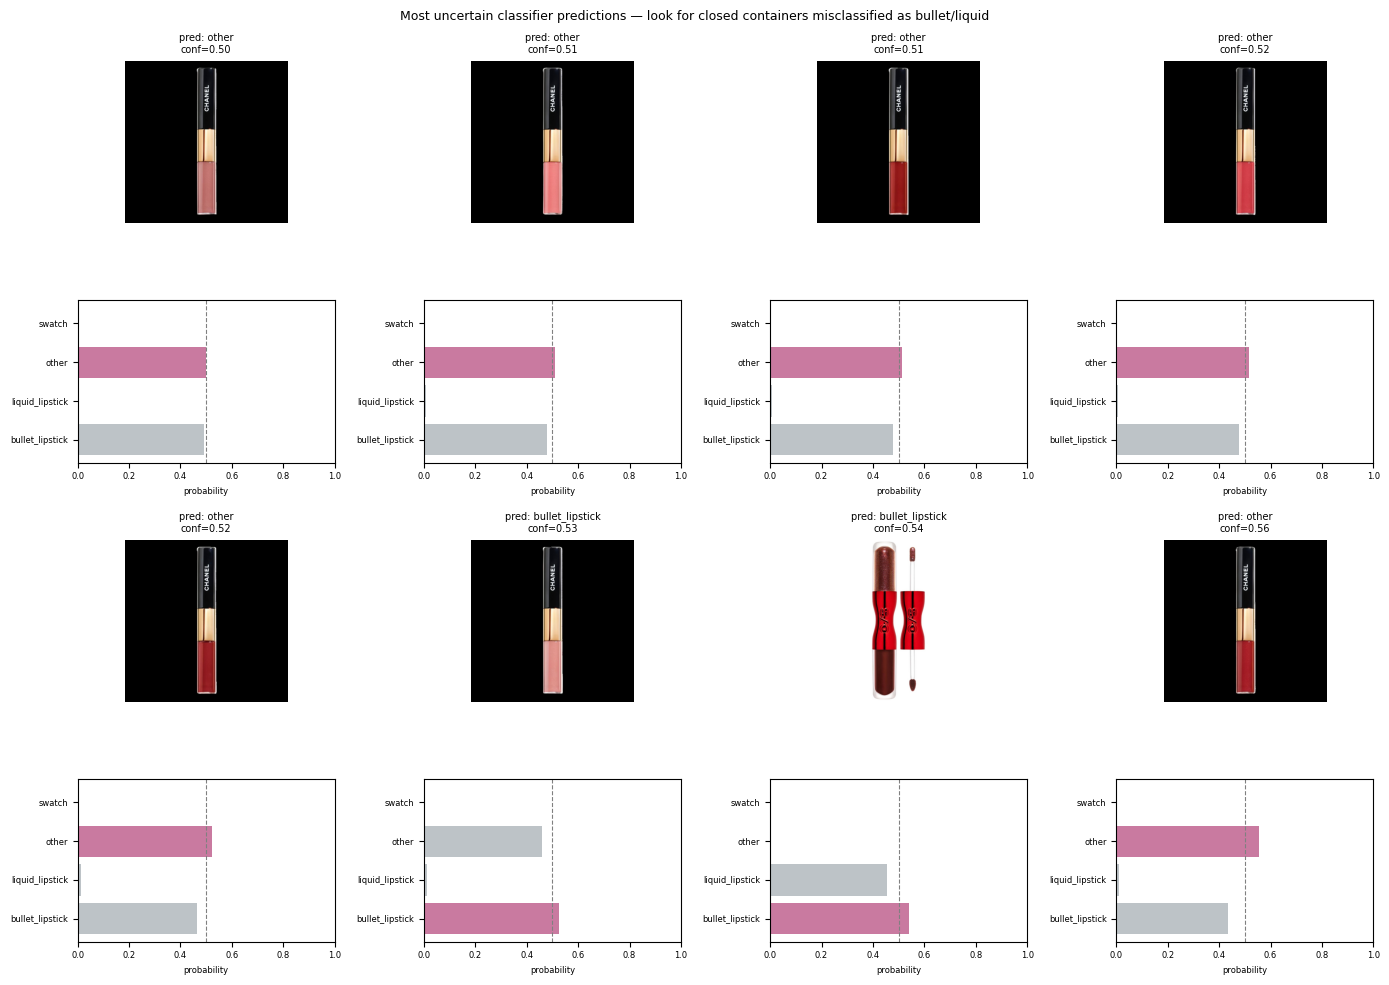

In [191]:
n_show = min(8, len(pool_clf_df))
if n_show == 0:
    print('Pool is empty — all images in IMG_DIRS are already in the classifier training/val sets.')
else:
    top = pool_clf_df.head(n_show).reset_index(drop=True)
    ncols = 4
    nrows = int(np.ceil(n_show / ncols))
    fig, axes = plt.subplots(nrows * 2, ncols, figsize=(ncols * 3.5, nrows * 5))
    axes = axes.reshape(nrows * 2, ncols)

    for i, row in top.iterrows():
        r, c = (i // ncols) * 2, i % ncols
        img = np.array(Image.open(row['img_path']).convert('RGB'))
        axes[r, c].imshow(img)
        axes[r, c].set_title(
            f"pred: {row['pred_label']}\nconf={row['confidence']:.2f}", fontsize=7
        )
        axes[r, c].axis('off')

        probs = [row[f'p_{cls}'] for cls in CLASSES]
        bar_colors = ['#c97aa0' if CLASSES[j] == row['pred_label'] else '#bdc3c7'
                      for j in range(len(CLASSES))]
        axes[r+1, c].barh(CLASSES, probs, color=bar_colors)
        axes[r+1, c].set_xlim(0, 1)
        axes[r+1, c].axvline(0.5, color='gray', linestyle='--', linewidth=0.8)
        axes[r+1, c].tick_params(labelsize=6)
        axes[r+1, c].set_xlabel('probability', fontsize=6)

    for j in range(n_show, nrows * ncols):
        r, c = (j // ncols) * 2, j % ncols
        axes[r, c].axis('off')
        axes[r+1, c].axis('off')

    plt.suptitle(
        'Most uncertain classifier predictions — look for closed containers misclassified as bullet/liquid',
        fontsize=9
    )
    plt.tight_layout()
    plt.show()


In [143]:
export_path = os.path.join(ANN_DIR, 'active_learning_queue.csv')
pool_clf_df[['img_name', 'img_path', 'pred_label', 'confidence', 'uncertainty']].to_csv(export_path, index=False)
print(f'Exported {len(pool_clf_df)} candidates → {export_path}')
print('Review these images and add a "correct_label" column where the prediction is wrong.')


Exported 48 candidates → /Users/connie/dev/lipstick_color_extraction/data/annotations/active_learning_queue.csv
Review these images and add a "correct_label" column where the prediction is wrong.


### Step 2: Correct labels and retrain Stage 1

1. Open `data/annotations/active_learning_queue.csv`: prioritize images with the lowest confidence
2. Add a `correct_label` column with the true container type: `bullet_lipstick`, `liquid_lipstick`, `swatch`, or `other`
3. Run the retrain cell below: it merges the corrected labels with the existing training set, recalculates class weights, and retrains Stage 1

No mask drawing needed: this is label correction only.

In [192]:
NEW_LABELS = os.path.join(ANN_DIR, 'active_learning_queue.csv')

if not os.path.exists(NEW_LABELS):
    print('No corrected labels yet.')
    print(f'Expected: {NEW_LABELS}')
else:
    new_labels = (
        pd.read_csv(NEW_LABELS)
        .pipe(lambda d: d[d['correct_label'].notna()])
        .rename(columns={'correct_label': 'label'})
    )
    # img_name in this file is already the disk filename (from os.listdir)
    new_labels['img_name_disk'] = new_labels['img_name']
    print(f'{len(new_labels)} corrected labels loaded')
    print(new_labels['label'].value_counts().to_string())

    # ── Expand dataset (original + corrected) ──────────────────────────────
    clf_all = pd.concat([
        labels_df[['img_name', 'img_name_disk', 'label']],
        new_labels[['img_name', 'img_name_disk', 'label']]
    ], ignore_index=True).drop_duplicates(subset='img_name_disk')

    counts2 = clf_all['label'].value_counts()
    total2  = len(clf_all)
    cw2 = torch.tensor(
        [total2 / (len(CLASSES) * counts2.get(c, 1)) for c in CLASSES], dtype=torch.float
    )
    print('Updated class weights:', {c: round(w, 3) for c, w in zip(CLASSES, cw2.tolist())})

    ann_closed2 = set(os.listdir(IMG_CLOSED))
    force2      = clf_all[clf_all['img_name_disk'].isin(ann_closed2)]
    to_split2   = clf_all[~clf_all['img_name_disk'].isin(ann_closed2) & clf_all['img_name_disk'].notna()]
    rest2, val2 = train_test_split(to_split2, test_size=0.2, stratify=to_split2['label'], random_state=42)
    train2      = pd.concat([force2, rest2]).reset_index(drop=True)
    print(f'Expanded — train: {len(train2)}  val: {len(val2)}  (was: {len(train_df)} / {len(val_df)})')

    # ── Fine-tune the existing classifier (don't retrain from scratch) ──────
    clf_al = build_classifier(num_classes=len(CLASSES), pretrained=False).to(DEVICE)
    clf_al.load_state_dict(torch.load(clf_ckpt, map_location=DEVICE)['model_state_dict'])

    ckpt_al   = os.path.join(MODELS_DIR, 'resnet18_classifier_al.pth')
    crit_al   = nn.CrossEntropyLoss(weight=cw2.to(DEVICE))
    tr_loader = DataLoader(ProductDataset(train2, train_tf), batch_size=32, shuffle=True, num_workers=0)
    va_loader = DataLoader(ProductDataset(val2,   val_tf),   batch_size=32, num_workers=0)

    for p in clf_al.parameters(): p.requires_grad = True
    opt_al   = torch.optim.Adam(clf_al.parameters(), lr=1e-5)
    sched_al = torch.optim.lr_scheduler.StepLR(opt_al, step_size=5, gamma=0.1)
    best_va  = 0.0
    print('Fine-tuning on expanded dataset (10 epochs, lr=1e-5)')
    for epoch in range(10):
        _, tr = run_epoch(clf_al, tr_loader, crit_al, opt_al, DEVICE)
        _, va = run_epoch(clf_al, va_loader, crit_al, opt_al, DEVICE, train=False)
        sched_al.step()
        print(f'  {epoch+1:2d}: train={tr:.3f}  val={va:.3f}')
        if va > best_va:
            best_va = va
            torch.save({'model_state_dict': clf_al.state_dict(), 'classes': CLASSES}, ckpt_al)

    print(f'\nBest val acc: {best_va:.3f}  →  {ckpt_al}')
    clf = clf_al
    print('Global `clf` updated to fine-tuned classifier.')


48 corrected labels loaded
label
other              17
swatch             16
liquid_lipstick     9
bullet_lipstick     6
Updated class weights: {'bullet_lipstick': 1.012, 'liquid_lipstick': 1.314, 'other': 1.816, 'swatch': 0.588}
Expanded — train: 204  val: 42  (was: 162 / 36)
Fine-tuning on expanded dataset (10 epochs, lr=1e-5)
   1: train=0.985  val=0.976
   2: train=0.985  val=0.976
   3: train=0.995  val=0.976
   4: train=1.000  val=0.976
   5: train=1.000  val=0.976
   6: train=1.000  val=0.976
   7: train=0.990  val=0.976
   8: train=1.000  val=0.976
   9: train=1.000  val=0.976
  10: train=1.000  val=0.976

Best val acc: 0.976  →  /Users/connie/dev/lipstick_color_extraction/models/resnet18_classifier_al.pth
Global `clf` updated to fine-tuned classifier.


                 precision    recall  f1-score   support

bullet_lipstick       1.00      0.92      0.96        12
liquid_lipstick       0.90      1.00      0.95         9
          other       1.00      1.00      1.00         1
         swatch       1.00      1.00      1.00        20

       accuracy                           0.98        42
      macro avg       0.97      0.98      0.98        42
   weighted avg       0.98      0.98      0.98        42



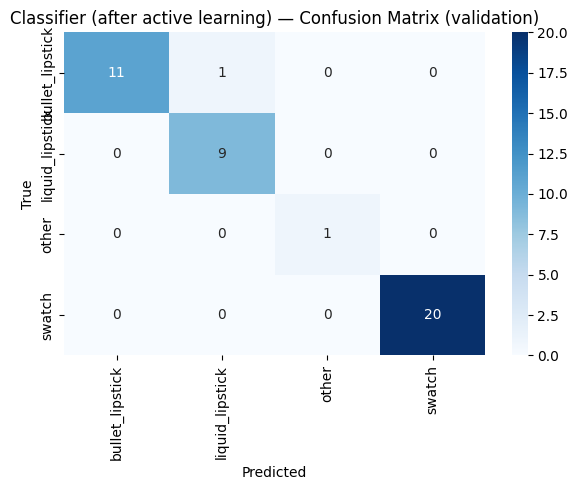

In [193]:
# Evaluate fine-tuned classifier on the expanded validation set
clf.eval()
preds_al, targets_al = [], []
with torch.no_grad():
    for x, y in DataLoader(ProductDataset(val2, val_tf), batch_size=32):
        preds_al.extend(clf(x.to(DEVICE)).argmax(1).cpu().tolist())
        targets_al.extend(y.tolist())

print(classification_report(targets_al, preds_al, target_names=CLASSES))

cm_al = confusion_matrix(targets_al, preds_al)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_al, annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES,
            cmap='Blues', ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Classifier (after active learning) — Confusion Matrix (validation)')
plt.tight_layout()
plt.show()


### Step 3: What active learning actually improved

The routing accuracy table below shows the original vs fine-tuned classifier on `labels_df`: nearly identical, because those are the **training and validation images** the original model already knew. Active learning added the pool images (48 new examples, mostly `other`) to improve generalization to **unseen** images, not to fix images the model already had.

The real improvement is not visible here: the pool images were corrected for container type, not color, so there is no ground-truth LAB to compute Delta E on them. What changed is the classifier's ability to correctly route new closed/transparent-container images it encounters in production: images it previously split between `other` and `bullet`/`liquid` with low confidence.

In [203]:
def run_e2e(classifier):
    """Run full pipeline using classifier predictions for routing."""
    classifier.eval(); seg.eval(); seg_other.eval()
    rows = []
    for _, row in labels_df.iterrows():
        if pd.isna(row['img_name_disk']):
            continue
        img_path = find_image(row['img_name_disk'])
        if img_path is None:
            continue
        pred_label, _, _ = score_clf_uncertainty(classifier, img_path, DEVICE)
        img = np.array(Image.open(img_path).convert('RGB'))
        if pred_label == 'swatch':
            lab = extract_swatch_color(img)
        elif pred_label in SEG_CLASSES:
            mask = predict_mask(seg, img_path, DEVICE)
            lab  = extract_masked_color(img, mask)
        else:  # other → dominant cluster (best strategy per Section 6)
            mask = predict_mask(seg_other, img_path, DEVICE)
            lab  = extract_dominant_cluster_color(img, mask)
        rows.append({
            'img_name':         row['img_name'],
            'true_label':       row['label'],
            'pred_label':       pred_label,
            'routed_correctly': row['label'] == pred_label,
        })
    return pd.DataFrame(rows)

# ── Run both classifiers ──────────────────────────────────────────────────────
clf_orig = build_classifier(num_classes=len(CLASSES), pretrained=False).to(DEVICE)
clf_orig.load_state_dict(torch.load(clf_ckpt, map_location=DEVICE)['model_state_dict'])

e2e_orig_df = run_e2e(clf_orig)
e2e_al_df   = run_e2e(clf)

# ── Routing accuracy table ────────────────────────────────────────────────────
acc_rows = []
for cls in CLASSES:
    orig_cls     = e2e_orig_df[e2e_orig_df['true_label'] == cls]
    al_cls       = e2e_al_df[e2e_al_df['true_label'] == cls]
    n_wrong_orig = (~orig_cls['routed_correctly']).sum()
    n_wrong_al   = (~al_cls['routed_correctly']).sum()
    acc_rows.append({
        'class':      cls,
        'n':          len(orig_cls),
        'original':   f"{orig_cls['routed_correctly'].mean():.0%}  ({n_wrong_orig} wrong)",
        'fine-tuned': f"{al_cls['routed_correctly'].mean():.0%}  ({n_wrong_al} wrong)",
    })

acc_tbl = pd.DataFrame(acc_rows).set_index('class')
print('Routing accuracy on labeled images (train + val — not a held-out test)\n')
print(acc_tbl.to_string())
print(f'\nOverall — original: {e2e_orig_df["routed_correctly"].mean():.1%}   '
      f'fine-tuned: {e2e_al_df["routed_correctly"].mean():.1%}')
print('\nBoth classifiers are near-perfect here because these are training/val images.')
print('Active learning improved generalization to unseen images (the 48-image pool),')
print('which cannot be evaluated for Delta E since pool labels are container type only, not color.')

Routing accuracy on labeled images (train + val — not a held-out test)

                  n         original       fine-tuned
class                                                
bullet_lipstick  55  100%  (0 wrong)   98%  (1 wrong)
liquid_lipstick  38   97%  (1 wrong)  100%  (0 wrong)
other            16  100%  (0 wrong)  100%  (0 wrong)
swatch           89  100%  (0 wrong)  100%  (0 wrong)

Overall — original: 99.5%   fine-tuned: 99.5%

Both classifiers are near-perfect here because these are training/val images.
Active learning improved generalization to unseen images (the 48-image pool),
which cannot be evaluated for Delta E since pool labels are container type only, not color.
